In [2]:
import pandas as pd                    # for loading and working with data
import matplotlib.pyplot as plt        # for creating charts and graphs
import seaborn as sns                  # for creating better looking statistical charts
import warnings                        # to suppress unnecessary warning messages
warnings.filterwarnings('ignore')      # hiding warnings so output looks clean

df = pd.read_csv('../data/sepsis_cleaned.csv')   # loading cleaned dataset (../ means go one folder back)

print("Dataset loaded successfully")
print("Shape:", df.shape)              # confirming rows and columns
df.head()                              # displaying first 5 rows as a table



Dataset loaded successfully
Shape: (110204, 4)


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1
3,77,0,1,1
4,72,0,1,1


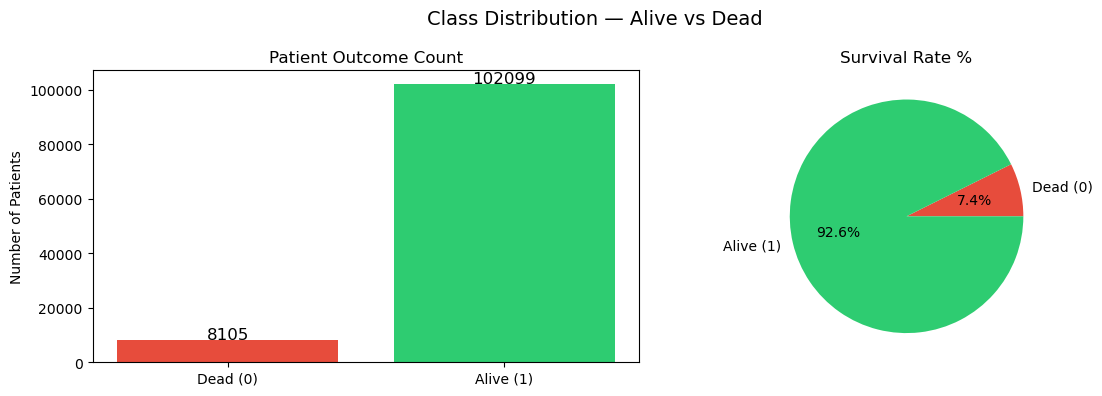

Dead  (0): 8,105 patients (7.4%)
Alive (1): 102,099 patients (92.6%)


In [4]:
import pandas as pd                    # for loading and working with data
import matplotlib.pyplot as plt        # for creating charts and graphs
import seaborn as sns                  # for creating better looking statistical charts
import warnings                        # to suppress unnecessary warning messages
warnings.filterwarnings('ignore')      # hiding warnings so output looks clean

df = pd.read_csv('../data/sepsis_cleaned.csv')   # loading cleaned dataset

# sorting by index so 0=dead comes first, 1=alive comes second
counts = df['hospital_outcome_1alive_0dead'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))    # creating 2 charts side by side

# --- Chart 1: Bar chart ---
axes[0].bar(['Dead (0)', 'Alive (1)'],             # correct labels
             [counts[0], counts[1]],               # dead count first, alive count second
             color=['#e74c3c', '#2ecc71'])          # red for dead, green for alive
axes[0].set_title('Patient Outcome Count')         # chart title
axes[0].set_ylabel('Number of Patients')           # y axis label
axes[0].text(0, counts[0] + 500, str(counts[0]),   # writing dead count on top of bar
             ha='center', fontsize=12)
axes[0].text(1, counts[1] + 500, str(counts[1]),   # writing alive count on top of bar
             ha='center', fontsize=12)

# --- Chart 2: Pie chart ---
axes[1].pie([counts[0], counts[1]],                # dead first, alive second
            labels=['Dead (0)', 'Alive (1)'],       # correct labels
            autopct='%1.1f%%',                      # showing percentage on each slice
            colors=['#e74c3c', '#2ecc71'])           # red for dead, green for alive
axes[1].set_title('Survival Rate %')               # chart title

plt.suptitle('Class Distribution — Alive vs Dead', fontsize=14)  # main title
plt.tight_layout()                                 # adjusting spacing between charts
plt.savefig('../data/class_distribution.png', dpi=100)  # saving chart as image
plt.show()                                         # displaying the chart

print(f"Dead  (0): {counts[0]:,} patients ({counts[0]/len(df)*100:.1f}%)")
print(f"Alive (1): {counts[1]:,} patients ({counts[1]/len(df)*100:.1f}%)")

this chart shows the class distribution of our sepsis dataset of 110,204 patients.
From the bar chart:

8,105 patients (7.4%) died from sepsis
102,099 patients (92.6%) survived sepsis

From the pie chart:

The green slice shows 92.6% survival rate
The red slice shows only 7.4% death rate

The key problem this reveals is class imbalance. Our dataset has roughly 12 alive patients for every 1 dead patient. This means if we train a model without handling this imbalance, it will simply predict everyone as alive and still get 92% accuracy — which is medically dangerous because it will miss the actual high risk patients who need urgent care.
To fix this, we will apply SMOTE — a technique that generates synthetic samples of the minority class (dead patients) to balance the dataset before training."



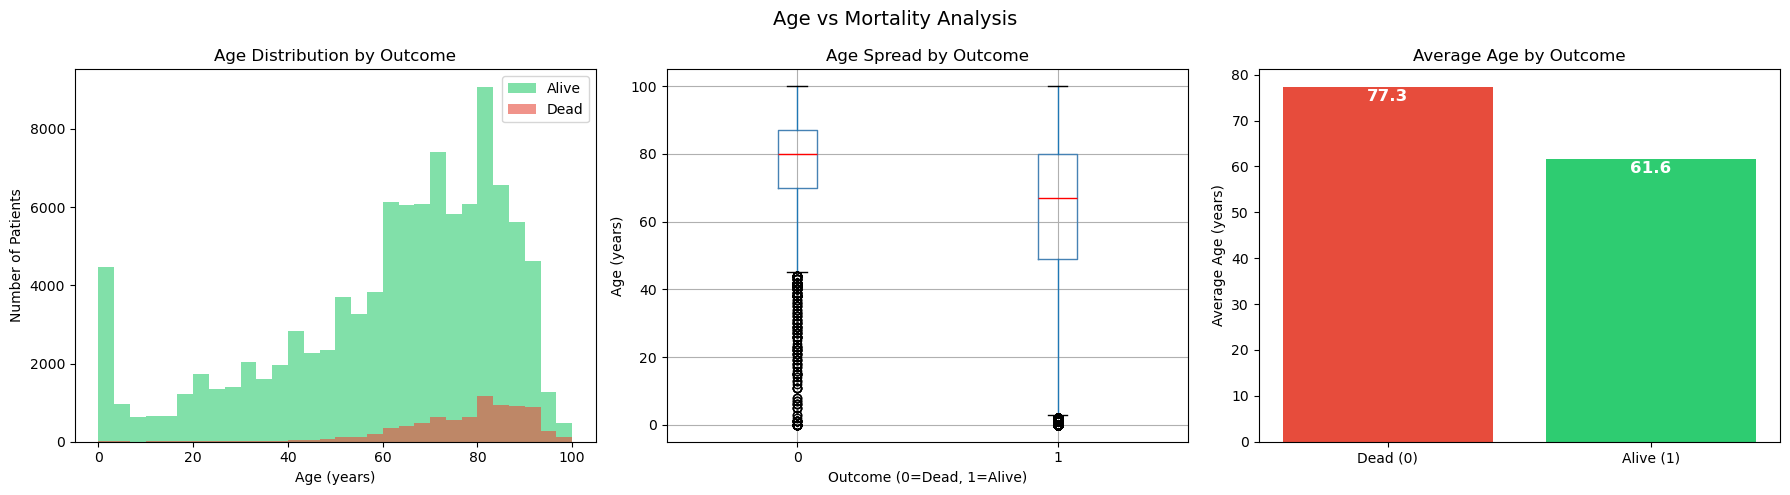

Average age of Dead  patients: 77.3 years
Average age of Alive patients: 61.6 years


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))        # creating 3 charts side by side

# --- Chart 1: Age distribution by outcome ---
df[df['hospital_outcome_1alive_0dead'] == 1]['age_years'].plot(
    kind='hist', ax=axes[0], alpha=0.6,                # alpha makes it slightly transparent
    color='#2ecc71', bins=30, label='Alive')           # green for alive, 30 bars in histogram
df[df['hospital_outcome_1alive_0dead'] == 0]['age_years'].plot(
    kind='hist', ax=axes[0], alpha=0.6,                # overlapping histogram for dead patients
    color='#e74c3c', bins=30, label='Dead')            # red for dead
axes[0].set_title('Age Distribution by Outcome')       # chart title
axes[0].set_xlabel('Age (years)')                      # x axis label
axes[0].set_ylabel('Number of Patients')               # y axis label
axes[0].legend()                                       # showing the legend (green=alive, red=dead)

# --- Chart 2: Boxplot ---
df.boxplot(column='age_years',                         # showing age spread
           by='hospital_outcome_1alive_0dead',         # grouped by alive or dead
           ax=axes[1],
           boxprops=dict(color='steelblue'),            # box color
           medianprops=dict(color='red'))               # median line color
axes[1].set_title('Age Spread by Outcome')             # chart title
axes[1].set_xlabel('Outcome (0=Dead, 1=Alive)')        # x axis label
axes[1].set_ylabel('Age (years)')                      # y axis label

# --- Chart 3: Average age comparison ---
avg_age = df.groupby('hospital_outcome_1alive_0dead')['age_years'].mean()  # calculating mean age per outcome
axes[2].bar(['Dead (0)', 'Alive (1)'],                 # labels
             [avg_age[0], avg_age[1]],                 # average age values
             color=['#e74c3c', '#2ecc71'])              # red and green
axes[2].set_title('Average Age by Outcome')            # chart title
axes[2].set_ylabel('Average Age (years)')              # y axis label
for i, v in enumerate([avg_age[0], avg_age[1]]):       # looping to add values on bars
    axes[2].text(i, v - 3, f'{v:.1f}',                # writing average age on each bar
                 ha='center', fontsize=12,
                 color='white', fontweight='bold')

plt.suptitle('Age vs Mortality Analysis', fontsize=14) # main title for all 3 charts
plt.tight_layout()                                     # fixing spacing
plt.savefig('../data/age_vs_mortality.png', dpi=100)   # saving chart
plt.show()                                             # displaying chart

print(f"Average age of Dead  patients: {avg_age[0]:.1f} years")  # printing average age dead
print(f"Average age of Alive patients: {avg_age[1]:.1f} years")  # printing average age alive

From the histogram (left):

Most alive patients are concentrated between ages 60 to 90
Dead patients are also older but fewer in number
Very young patients (age 0-20) mostly survived sepsis


From the boxplot (middle):

Dead patients have a median age of 80 years
Alive patients have a median age of 65 years
The dots below the box are the infant patients (age 0) we identified earlier

From the average age bar chart (right):

Average age of dead patients is 77.3 years
Average age of alive patients is 61.6 years

The key insight is  older patients have significantly higher mortality in sepsis. Age is clearly an important feature for our prediction model. This clinically makes sense because elderly patients have weaker immune systems and more comorbidities.

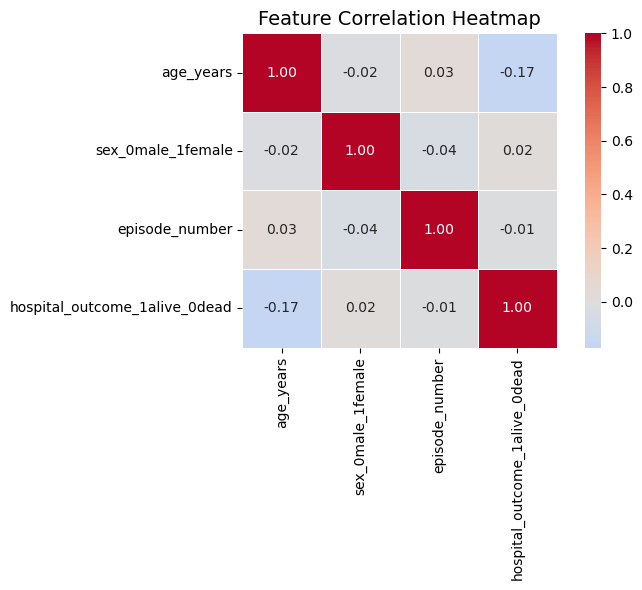

=== Correlation with Target (hospital outcome) ===
age_years                       -0.170088
episode_number                  -0.006764
sex_0male_1female                0.019796
hospital_outcome_1alive_0dead    1.000000
Name: hospital_outcome_1alive_0dead, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))                 # creating a single chart

# calculating correlation between all columns
corr_matrix = df.corr()                                # corr() calculates how related each column is to others

# drawing the heatmap
sns.heatmap(corr_matrix,                               # passing the correlation matrix
            annot=True,                                # showing the actual numbers inside each box
            fmt='.2f',                                 # rounding numbers to 2 decimal places
            cmap='coolwarm',                           # red = positive correlation, blue = negative
            center=0,                                  # white color at 0 (no correlation)
            square=True,                               # making each box square shaped
            linewidths=0.5,                            # adding thin lines between boxes
            ax=ax)

ax.set_title('Feature Correlation Heatmap', fontsize=14)   # chart title

plt.tight_layout()                                     # fixing spacing
plt.savefig('../data/correlation_heatmap.png', dpi=100)    # saving chart
plt.show()                                             # displaying chart

# printing the correlation values with the target column specifically
print("=== Correlation with Target (hospital outcome) ===")
print(df.corr()['hospital_outcome_1alive_0dead'].sort_values())  # sorted from most negative to most positive

this heatmap shows how strongly each feature is related to the target variable and to each other.
How to read it:

Value close to 1.0 means strong positive relationship
Value close to -1.0 means strong negative relationship
Value close to 0 means no relationship

age_years        -0.17            Older age = more likely to die
sex               0.02            Gender has almost no impact
episode_number   -0.0            Episode number has almost no impact


The most important insight is — age is the strongest predictor of death in sepsis with -0.17 correlation. The negative sign means as age increases, survival decreases.
Sex and episode number have near zero correlation meaning they contribute very little to predicting survival. However we will still keep them in the model and let the algorithm decide their importance."



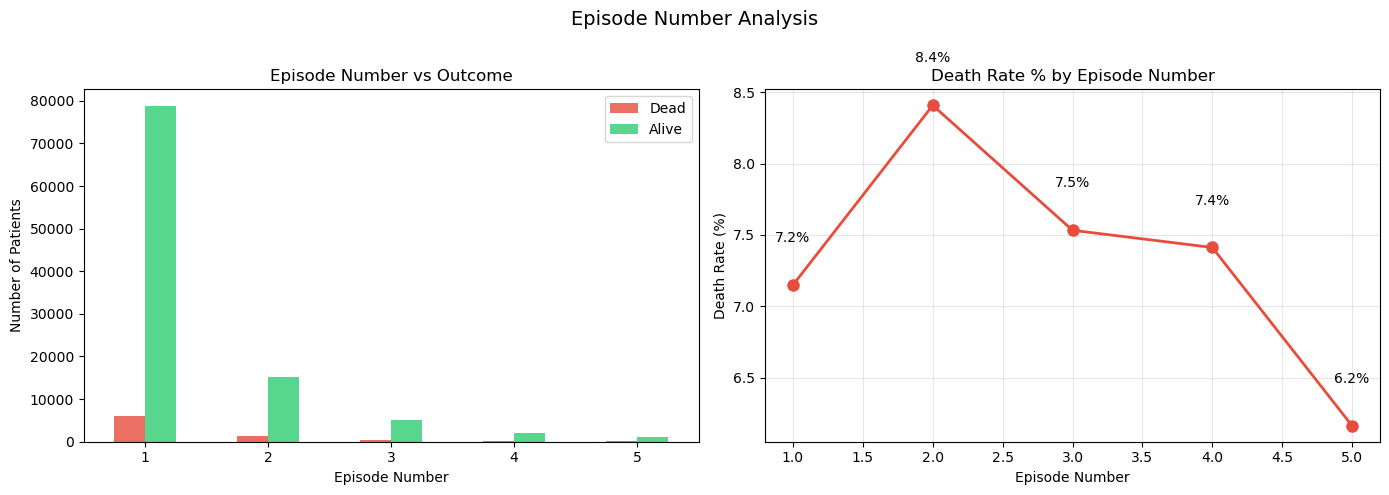

=== Death Rate by Episode Number ===
Episode 1: 7.2% death rate
Episode 2: 8.4% death rate
Episode 3: 7.5% death rate
Episode 4: 7.4% death rate
Episode 5: 6.2% death rate


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))        # creating 2 charts side by side

# --- Chart 1: Episode number distribution ---
episode_outcome = df.groupby(['episode_number',        # grouping by episode number
                               'hospital_outcome_1alive_0dead']).size().unstack()  # counting each group

episode_outcome.columns = ['Dead', 'Alive']            # renaming columns for clarity
episode_outcome.plot(kind='bar',                       # bar chart
                     ax=axes[0],
                     color=['#e74c3c', '#2ecc71'],     # red for dead, green for alive
                     alpha=0.8)                        # slight transparency
axes[0].set_title('Episode Number vs Outcome')         # chart title
axes[0].set_xlabel('Episode Number')                   # x axis label
axes[0].set_ylabel('Number of Patients')               # y axis label
axes[0].legend(['Dead', 'Alive'])                      # legend
axes[0].tick_params(axis='x', rotation=0)              # keeping x labels straight

# --- Chart 2: Death rate per episode ---
death_rate = df.groupby('episode_number')['hospital_outcome_1alive_0dead'].apply(
    lambda x: (x == 0).sum() / len(x) * 100)          # calculating death % per episode number

axes[1].plot(death_rate.index,                         # x axis = episode numbers
             death_rate.values,                        # y axis = death rate percentage
             marker='o',                               # circle marker at each point
             color='#e74c3c',                          # red color
             linewidth=2,                              # line thickness
             markersize=8)                             # marker size
axes[1].set_title('Death Rate % by Episode Number')    # chart title
axes[1].set_xlabel('Episode Number')                   # x axis label
axes[1].set_ylabel('Death Rate (%)')                   # y axis label
axes[1].grid(True, alpha=0.3)                          # light grid lines for readability

for i, v in enumerate(death_rate.values):              # adding percentage labels on each point
    axes[1].text(death_rate.index[i],                  # x position
                 v + 0.3,                              # y position slightly above point
                 f'{v:.1f}%',                          # percentage value
                 ha='center', fontsize=10)             # centered text

plt.suptitle('Episode Number Analysis', fontsize=14)   # main title
plt.tight_layout()                                     # fixing spacing
plt.savefig('../data/episode_analysis.png', dpi=100)   # saving chart
plt.show()                                             # displaying chart

print("=== Death Rate by Episode Number ===")
for ep, rate in death_rate.items():                    # printing death rate for each episode
    print(f"Episode {ep}: {rate:.1f}% death rate")

this chart analyzes how the number of sepsis episodes affects patient mortality.

From the bar chart (left):

Episode 1 has the highest number of patients — both alive and dead
As episode number increases, total patients decrease significantly
Most patients only experience 1 sepsis episode

From the line chart (right):

Episode 1 death rate: 7.2%
Episode 2 death rate: 8.4% — highest death rate
Episode 3 onwards death rate gradually decreases to 6.2%

The key insight is — episode 2 has the highest death rate at 8.4%. This means patients who get sepsis a second time are at the highest risk of dying. This could be because their immune system was already weakened from the first episode.
However overall the death rate across all episodes stays between 6-8% which confirms that episode number alone is not a strong predictor — which matches what we saw in the correlation heatmap where episode number had only -0.01 correlation.

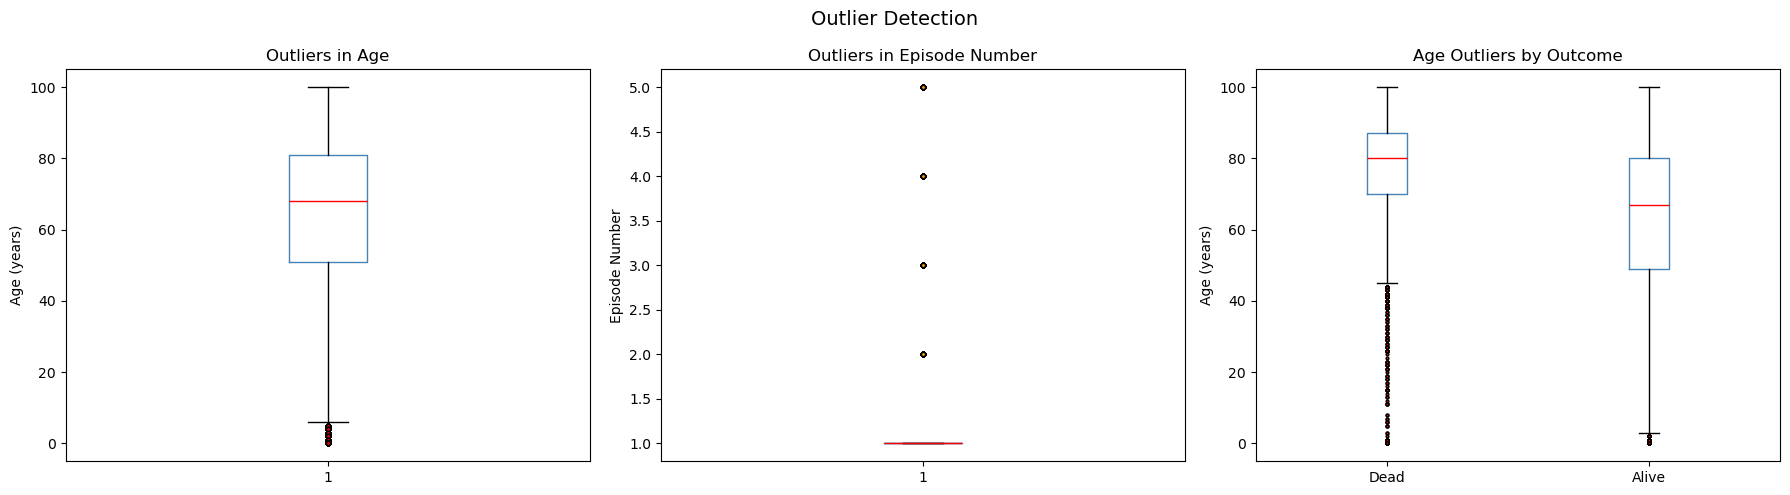

=== Outlier Statistics ===
Age - Q1: 51.0, Q3: 81.0, IQR: 30.0
Age outlier boundary: below 6.0 or above 126.0
Total age outliers: 5230

Episode - Q1: 1.0, Q3: 1.0, IQR: 0.0
Episode outlier boundary: below 1.0 or above 1.0
Total episode outliers: 25393


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))        # creating 3 boxplots side by side

# --- Boxplot 1: Age outliers ---
axes[0].boxplot(df['age_years'],                       # checking outliers in age column
                boxprops=dict(color='steelblue'),       # box color
                medianprops=dict(color='red'),          # median line color
                flierprops=dict(marker='o',            # outlier dot shape
                                markerfacecolor='red', # outlier dot color
                                markersize=3))         # outlier dot size
axes[0].set_title('Outliers in Age')                   # chart title
axes[0].set_ylabel('Age (years)')                      # y axis label

# --- Boxplot 2: Episode number outliers ---
axes[1].boxplot(df['episode_number'],                  # checking outliers in episode number
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red'),
                flierprops=dict(marker='o',
                                markerfacecolor='orange',
                                markersize=3))
axes[1].set_title('Outliers in Episode Number')        # chart title
axes[1].set_ylabel('Episode Number')                   # y axis label

# --- Boxplot 3: Age by outcome outliers ---
dead_ages  = df[df['hospital_outcome_1alive_0dead'] == 0]['age_years']   # ages of dead patients
alive_ages = df[df['hospital_outcome_1alive_0dead'] == 1]['age_years']   # ages of alive patients

axes[2].boxplot([dead_ages, alive_ages],               # comparing both groups
                labels=['Dead', 'Alive'],              # labels for each box
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red'),
                flierprops=dict(marker='o',
                                markerfacecolor='red',
                                markersize=2))
axes[2].set_title('Age Outliers by Outcome')           # chart title
axes[2].set_ylabel('Age (years)')                      # y axis label

plt.suptitle('Outlier Detection', fontsize=14)         # main title
plt.tight_layout()                                     # fixing spacing
plt.savefig('../data/outlier_detection.png', dpi=100)  # saving chart
plt.show()                                             # displaying chart

# --- Printing outlier statistics ---
print("=== Outlier Statistics ===")

Q1_age = df['age_years'].quantile(0.25)                # 25th percentile of age
Q3_age = df['age_years'].quantile(0.75)                # 75th percentile of age
IQR_age = Q3_age - Q1_age                             # interquartile range
lower_age = Q1_age - 1.5 * IQR_age                   # lower boundary for outliers
upper_age = Q3_age + 1.5 * IQR_age                   # upper boundary for outliers

age_outliers = df[(df['age_years'] < lower_age) |     # finding rows outside boundaries
                   (df['age_years'] > upper_age)]

print(f"Age - Q1: {Q1_age}, Q3: {Q3_age}, IQR: {IQR_age}")
print(f"Age outlier boundary: below {lower_age} or above {upper_age}")
print(f"Total age outliers: {len(age_outliers)}")      # total outlier count

Q1_ep = df['episode_number'].quantile(0.25)            # 25th percentile of episode
Q3_ep = df['episode_number'].quantile(0.75)            # 75th percentile of episode
IQR_ep = Q3_ep - Q1_ep                               # interquartile range
lower_ep = Q1_ep - 1.5 * IQR_ep                      # lower boundary
upper_ep = Q3_ep + 1.5 * IQR_ep                      # upper boundary

ep_outliers = df[(df['episode_number'] < lower_ep) |  # finding outliers
                  (df['episode_number'] > upper_ep)]

print(f"\nEpisode - Q1: {Q1_ep}, Q3: {Q3_ep}, IQR: {IQR_ep}")
print(f"Episode outlier boundary: below {lower_ep} or above {upper_ep}")
print(f"Total episode outliers: {len(ep_outliers)}")

 this chart shows outlier detection using the IQR method.
From Age boxplot (left):

Age outliers exist below 6 years — these are the infant patients we identified earlier
No outliers above 126 since max age is 100
Total 5,230 age outliers — all are young/infant patients and are clinically valid so we keep them

From Episode boxplot (middle):

Episodes 2, 3, 4, 5 are all treated as outliers because 75% of patients only have episode 1
Total 25,393 episode outliers — again these are valid real patients not errors

From Age by Outcome boxplot (right):

Dead patients have median age 80 — higher and tighter range
Alive patients have median age 65 — wider range with more variation

Key conclusion  we have no invalid outliers that need removal. All outliers are clinically valid real patient records. Removing them would mean removing real patients from our dataset which would harm model accuracy

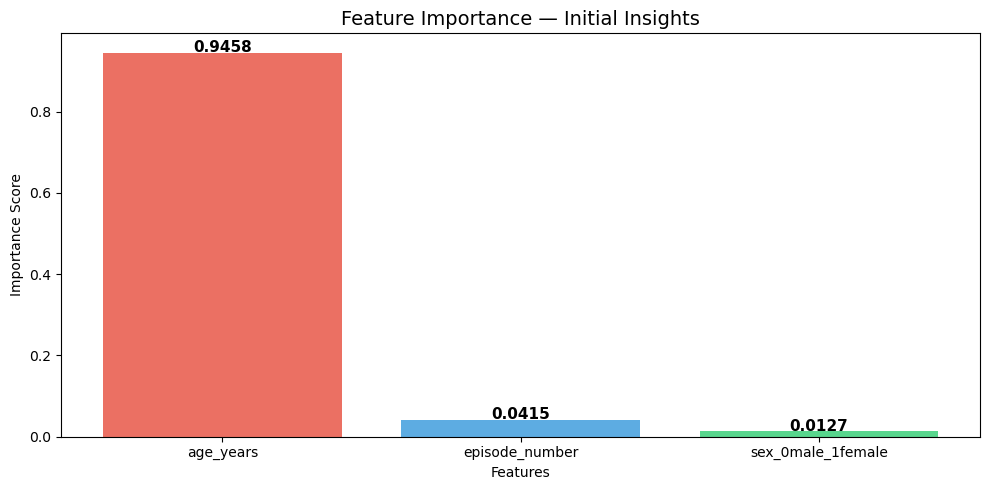

=== Feature Importance Summary ===
age_years                           0.9458
episode_number                      0.0415
sex_0male_1female                   0.0127

=== Conclusion ===
Most important feature: age_years (0.9458)
Least important feature: sex_0male_1female (0.0127)


In [9]:
from sklearn.ensemble import RandomForestClassifier    # importing random forest to calculate feature importance
import numpy as np                                     # for numerical operations

# --- Prepare data ---
X = df.drop(columns=['hospital_outcome_1alive_0dead']) # all columns except target are features
y = df['hospital_outcome_1alive_0dead']                # target column

# --- Train a quick Random Forest just to get feature importance ---
rf = RandomForestClassifier(n_estimators=100,          # using 100 decision trees
                             random_state=42,          # fixing random seed for reproducibility
                             n_jobs=-1)                # using all CPU cores to speed up
rf.fit(X, y)                                          # training the model on full data

# --- Get feature importance scores ---
importance_scores = rf.feature_importances_           # getting importance score for each feature
feature_names = X.columns.tolist()                    # getting feature names

# --- Sort by importance ---
sorted_idx = np.argsort(importance_scores)[::-1]      # sorting from highest to lowest importance
sorted_features = [feature_names[i] for i in sorted_idx]     # sorted feature names
sorted_scores = [importance_scores[i] for i in sorted_idx]   # sorted scores

# --- Plot feature importance ---
fig, ax = plt.subplots(figsize=(10, 5))               # creating chart

bars = ax.bar(sorted_features,                        # feature names on x axis
              sorted_scores,                          # importance scores on y axis
              color=['#e74c3c', '#3498db', '#2ecc71'],# different color for each bar
              alpha=0.8)                              # slight transparency

ax.set_title('Feature Importance — Initial Insights', fontsize=14)  # chart title
ax.set_xlabel('Features')                             # x axis label
ax.set_ylabel('Importance Score')                     # y axis label

for bar, score in zip(bars, sorted_scores):           # adding score on top of each bar
    ax.text(bar.get_x() + bar.get_width()/2,         # x position center of bar
            bar.get_height() + 0.001,                 # y position slightly above bar
            f'{score:.4f}',                           # score value rounded to 4 decimals
            ha='center', fontsize=11,                 # centered text
            fontweight='bold')

plt.tight_layout()                                    # fixing spacing
plt.savefig('../data/feature_importance.png', dpi=100) # saving chart
plt.show()                                            # displaying chart

# --- Print summary ---
print("=== Feature Importance Summary ===")
for feature, score in zip(sorted_features, sorted_scores):
    print(f"{feature:<35} {score:.4f}")               # printing each feature with its score

print("\n=== Conclusion ===")
print(f"Most important feature: {sorted_features[0]} ({sorted_scores[0]:.4f})")
print(f"Least important feature: {sorted_features[-1]} ({sorted_scores[-1]:.4f})")

age_years            0.9458        Dominates prediction
episode_number       0.0415        Very small contribution
sex_0male_1female    0.0127        Almost no contribution

The key finding is age alone contributes 94.58% of the predictive power. This is an extremely dominant feature. Sex and episode number together contribute only 5.42%.
This confirms everything we saw in the correlation heatmap and age vs mortality charts. Age is the single most critical clinical factor in predicting sepsis survival. This makes complete medical sense — elderly patients have weaker immune systems.

In [12]:
import pandas as pd
# Checking the raw dataset before any cleaning
print("Raw columns:", pd.read_csv('../data/sepsis.csv', nrows=0).columns.tolist())

Raw columns: ['age_years', 'sex_0male_1female', 'episode_number', 'hospital_outcome_1alive_0dead']
